In [23]:
import os
import torch
from torch.utils.data import Dataset
from pytorchvideo.data.encoded_video import EncodedVideo
from torchvision.transforms import Compose, Lambda, RandomHorizontalFlip, Normalize
from torchvision.transforms import Resize, CenterCrop


class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for cls in self.classes:
            folder = os.path.join(root_dir, cls)
            for f in os.listdir(folder):
                if f.endswith(".mp4") or f.endswith(".avi") or f.endswith(".mov"):
                    self.samples.append((os.path.join(folder, f), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
    
        video = EncodedVideo.from_path(path)
        clip = video.get_clip(start_sec=0, end_sec=4)
    
        video_tensor = clip["video"].float()  # (C, T, H, W) already correct
    
        #  NO PERMUTE HERE
        # video_tensor = video_tensor.permute(1, 0, 2, 3)
    
        if self.transform:
            video_tensor = self.transform(video_tensor)
    
        return video_tensor, label


In [24]:
class VideoNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, video):
        return (video - self.mean) / self.std


In [25]:
import torch
from torchvision.transforms import Compose, Lambda, Resize, CenterCrop
from pytorchvideo.transforms import UniformTemporalSubsample

mean = torch.tensor([0.45, 0.45, 0.45]).view(3,1,1,1)
std  = torch.tensor([0.225, 0.225, 0.225]).view(3,1,1,1)

train_transform = Compose([
    UniformTemporalSubsample(16),
    Lambda(lambda x: x / 255.0),

    Resize((256, 256), antialias=True),
    CenterCrop((256, 256)),

    Lambda(lambda x: (x - mean) / std),
])


In [26]:
import torch
from torchvision.transforms import Compose, Lambda, Resize, CenterCrop
from pytorchvideo.transforms import UniformTemporalSubsample

mean = torch.tensor([0.45, 0.45, 0.45]).view(3,1,1,1)
std  = torch.tensor([0.225, 0.225, 0.225]).view(3,1,1,1)

train_transform = Compose([
    UniformTemporalSubsample(16),
    Lambda(lambda x: x / 255.0),

    Resize((256, 256), antialias=True),
    CenterCrop((256, 256)),

    Lambda(lambda x: (x - mean) / std),
])

val_transform = Compose([
    UniformTemporalSubsample(16),
    Lambda(lambda x: x / 255.0),

    Resize((256, 256), antialias=True),
    CenterCrop((256, 256)),

    Lambda(lambda x: (x - mean) / std),
])

In [27]:
train_dir = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train"
val_dir   = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Validation"

train_dataset = VideoDataset(train_dir, transform=train_transform)
val_dataset   = VideoDataset(val_dir, transform=val_transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=2)


In [28]:
import torch.nn as nn

model = torch.hub.load("facebookresearch/pytorchvideo", "x3d_m", pretrained=True)

# Replace classifier for 6 classes
model.blocks[5].proj = nn.Linear(model.blocks[5].proj.in_features, 6)


Using cache found in C:\Users\Admin/.cache\torch\hub\facebookresearch_pytorchvideo_main


In [29]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [30]:
def train_epoch(model, loader):
    model.train()
    loss_sum, correct, total = 0, 0, 0

    for video, label in loader:
        video = video.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        out = model(video)
        loss = criterion(out, label)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (out.argmax(1) == label).sum().item()
        total += label.size(0)

    return loss_sum / len(loader), correct / total


def eval_epoch(model, loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.no_grad():
        for video, label in loader:
            video = video.to(device)
            label = label.to(device)

            out = model(video)
            loss = criterion(out, label)

            loss_sum += loss.item()
            correct += (out.argmax(1) == label).sum().item()
            total += label.size(0)

    return loss_sum / len(loader), correct / total


In [31]:
best_val_acc = 0.0
best_model_path = r"C:\Users\Admin\Desktop\AIML sem 3\project\Models\video_5_x3d.pth"


for epoch in range(15):

    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = eval_epoch(model, val_loader)

    print(f"Epoch {epoch+1}: TrainAcc={train_acc:.2f}, ValAcc={val_acc:.2f}")

    # --------------------------
    # Save Best Model
    # --------------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"🔥 Best Model Updated (ValAcc = {val_acc:.2f})")


Epoch 1: TrainAcc=0.17, ValAcc=0.17
🔥 Best Model Updated (ValAcc = 0.17)
Epoch 2: TrainAcc=0.30, ValAcc=0.22
🔥 Best Model Updated (ValAcc = 0.22)
Epoch 3: TrainAcc=0.37, ValAcc=0.33
🔥 Best Model Updated (ValAcc = 0.33)
Epoch 4: TrainAcc=0.43, ValAcc=0.33
Epoch 5: TrainAcc=0.67, ValAcc=0.44
🔥 Best Model Updated (ValAcc = 0.44)
Epoch 6: TrainAcc=0.87, ValAcc=0.44
Epoch 7: TrainAcc=0.90, ValAcc=0.56
🔥 Best Model Updated (ValAcc = 0.56)
Epoch 8: TrainAcc=0.90, ValAcc=0.61
🔥 Best Model Updated (ValAcc = 0.61)
Epoch 9: TrainAcc=0.97, ValAcc=0.61
Epoch 10: TrainAcc=1.00, ValAcc=0.44
Epoch 11: TrainAcc=1.00, ValAcc=0.72
🔥 Best Model Updated (ValAcc = 0.72)
Epoch 12: TrainAcc=1.00, ValAcc=0.56
Epoch 13: TrainAcc=1.00, ValAcc=0.72
Epoch 14: TrainAcc=1.00, ValAcc=0.72
Epoch 15: TrainAcc=1.00, ValAcc=0.67


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, CenterCrop, Lambda
from pytorchvideo.transforms import UniformTemporalSubsample
from pytorchvideo.data.encoded_video import EncodedVideo
import os


class VideoNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, video):
        return (video - self.mean) / self.std


mean = [0.45, 0.45, 0.45]
std  = [0.225, 0.225, 0.225]

video_transform = Compose([
    UniformTemporalSubsample(16),      # 16 frames
    Lambda(lambda x: x / 255.0),
    Resize((256, 256)),
    CenterCrop((256, 256)),
    VideoNormalize(mean, std),
])


model = torch.hub.load("facebookresearch/pytorchvideo", "x3d_m", pretrained=False)


model.blocks[5].proj = nn.Linear(model.blocks[5].proj.in_features, 6)

model_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\best_x3d_model.pth"
model.load_state_dict(torch.load(model_path, map_location="cpu"))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()


def predict_video(video_path, class_names):
    video = EncodedVideo.from_path(video_path)

    # Read first 2 seconds
    clip = video.get_clip(start_sec=0, end_sec=4)
    video_tensor = clip["video"].float()   # (C, T, H, W)

    # Apply transforms
    video_tensor = video_transform(video_tensor)

   
    video_tensor = video_tensor.unsqueeze(0).to(device)


    with torch.no_grad():
        output = model(video_tensor)
        prob = F.softmax(output, dim=1)[0]

    idx = torch.argmax(prob).item()
    confidence = prob[idx].item()

    return class_names[idx], confidence

test_dir = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Test"
train_dir = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Train1"

class_names = sorted(os.listdir(train_dir))

print("Classes:", class_names)
print("---- PREDICTIONS ----")

for file in os.listdir(test_dir):
    if file.endswith((".mp4", ".avi", ".mov")):
        path = os.path.join(test_dir, file)
        label, conf = predict_video(path, class_names)

        print(f"{file}  →  {label}  ({conf*100:.2f}% confidence)")


Using cache found in C:\Users\Admin/.cache\torch\hub\facebookresearch_pytorchvideo_main


Classes: ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
---- PREDICTIONS ----
Beautiful.mp4  →  Beautiful  (33.59% confidence)
Beautiful2.mp4  →  Beautiful  (35.12% confidence)
Beautiful3.mp4  →  Beautiful  (25.11% confidence)
Good_Morning.mp4  →  Good_Morning  (30.35% confidence)
Good_Morning2.mp4  →  Good_Morning  (33.34% confidence)
Good_Morning3.mp4  →  Good_Morning  (31.55% confidence)
Happy.mp4  →  Happy  (31.52% confidence)
Happy2.mp4  →  Good_Morning  (29.90% confidence)
Happy3.mp4  →  Good_Morning  (24.57% confidence)
Headache.mp4  →  Hello  (34.90% confidence)
Headache2.mp4  →  Headache  (34.09% confidence)
Headache3.mp4  →  Headache  (30.38% confidence)
Hello.mp4  →  Hello  (35.13% confidence)
Hello2.mp4  →  Hello  (35.19% confidence)
Hello3.mp4  →  Hello  (35.04% confidence)
Namaste.mp4  →  Namaste  (35.21% confidence)
Namaste2.mp4  →  Namaste  (35.20% confidence)
Namaste3.mp4  →  Namaste  (32.91% confidence)


Using cache found in C:\Users\Admin/.cache\torch\hub\facebookresearch_pytorchvideo_main


CLASSES: ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
---- BEST PREDICTIONS ----



C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Person1_Beautiful.mp4
  Actual    : Beautiful
  Predicted : Happy (21.91%)

Person1_GoodMorning.mp4 → Unknown class, skipped

Person1_Happy.mp4
  Actual    : Happy
  Predicted : Good_Morning (21.63%)

Person1_Headache.mp4
  Actual    : Headache
  Predicted : Headache (20.56%)

Person1_Hello.mp4
  Actual    : Hello
  Predicted : Headache (19.77%)

Person1_Namaste.mp4
  Actual    : Namaste
  Predicted : Namaste (30.31%)

========= CONFUSION MATRIX =========
[[0 0 1 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 1]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   Beautiful       0.00      0.00      0.00         1
Good_Morning       0.00      0.00      0.00         0
       Happy       0.00      0.00      0.00         1
    Headache       0.50      1.00      0.67         1
       Hello       0.00      0.00      0.00         1
     Namaste       1.00      1.00      1.00         1

    accuracy                      

C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

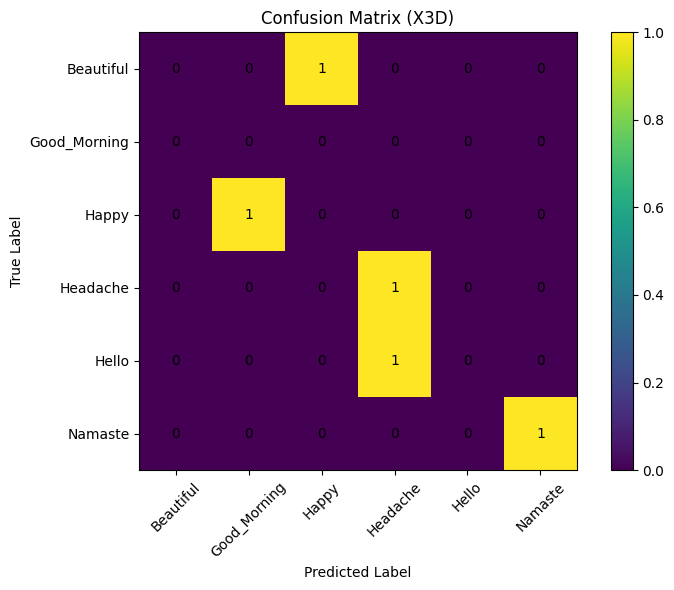

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, CenterCrop, Lambda
from pytorchvideo.transforms import UniformTemporalSubsample
from pytorchvideo.data.encoded_video import EncodedVideo
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report


class VideoNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, video):
        return (video - self.mean) / self.std


mean = [0.45, 0.45, 0.45]
std  = [0.225, 0.225, 0.225]

base_transform = Compose([
    Lambda(lambda x: x / 255.0),
    Resize((256, 256)),
    CenterCrop((256, 256)),
    VideoNormalize(mean, std),
])

subsample = UniformTemporalSubsample(16)


model = torch.hub.load("facebookresearch/pytorchvideo", "x3d_m", pretrained=False)
model.blocks[5].proj = nn.Linear(model.blocks[5].proj.in_features, 6)

model_path = r"C:\Users\Admin\Desktop\AIML sem 3\project\Models\video_5_x3d.pth"
model.load_state_dict(torch.load(model_path, map_location="cpu"))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

def predict_video_best(video_path, class_names):
    video = EncodedVideo.from_path(video_path)

    duration = video.duration
    if duration < 3:
        duration = 3

    segments = np.linspace(0, duration - 2, 4)
    probs = []

    for start in segments:
        clip = video.get_clip(start_sec=float(start), end_sec=float(start + 2))
        video_tensor = clip["video"].float()

        video_tensor = subsample(video_tensor)
        video_tensor = base_transform(video_tensor)
        video_tensor = video_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(video_tensor)
            prob = F.softmax(out, dim=1)[0].cpu().numpy()
            probs.append(prob)

    final_prob = np.mean(probs, axis=0)
    idx = np.argmax(final_prob)

    return class_names[idx], final_prob[idx]

test_dir = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\person\person1"
train_dir = r"C:\Users\Admin\Desktop\AIML sem 3\project\DataSets\Train"

class_names = sorted(os.listdir(train_dir))

print("CLASSES:", class_names)
print("---- BEST PREDICTIONS ----\n")

y_true = []
y_pred = []

for file in os.listdir(test_dir):
    if not file.lower().endswith((".mp4", ".avi", ".mov")):
        continue

    path = os.path.join(test_dir, file)

 
    name = os.path.splitext(file)[0]
    true_label_name = name.split("_", 1)[1]

    if true_label_name not in class_names:
        print(f"{file} → Unknown class, skipped\n")
        continue

    true_label = class_names.index(true_label_name)

    pred_label_name, conf = predict_video_best(path, class_names)
    pred_label = class_names.index(pred_label_name)

    y_true.append(true_label)
    y_pred.append(pred_label)

    print(f"{file}")
    print(f"  Actual    : {true_label_name}")
    print(f"  Predicted : {pred_label_name} ({conf*100:.2f}%)\n")

print("========= CONFUSION MATRIX =========")
cm = confusion_matrix(y_true, y_pred)
print(cm)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (X3D)")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


In [4]:
!pip install scikit-learn


In [6]:
import sys
print(sys.executable)


C:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe


In [17]:
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, CenterCrop, Lambda
from pytorchvideo.transforms import UniformTemporalSubsample
from pytorchvideo.data.encoded_video import EncodedVideo
import numpy as np
import os
import tempfile


class VideoNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, video):
        return (video - self.mean) / self.std


mean = [0.45, 0.45, 0.45]
std  = [0.225, 0.225, 0.225]

video_transform = Compose([
    UniformTemporalSubsample(16),
    Lambda(lambda x: x / 255.0),
    Resize((256, 256)),
    CenterCrop((256, 256)),
    VideoNormalize(mean, std),
])


model = torch.hub.load("facebookresearch/pytorchvideo", "x3d_m", pretrained=False)
model.blocks[5].proj = nn.Linear(model.blocks[5].proj.in_features, 6)

model_path = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\Models\best_x3d_model.pth"
model.load_state_dict(torch.load(model_path, map_location="cpu"))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

train_dir = r"C:\Users\Admin\Desktop\Sign_Language_Communicator\DataSets\Train1"
class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)


def predict_video(video_path, class_names):
    video = EncodedVideo.from_path(video_path)
    clip = video.get_clip(start_sec=0, end_sec=2)
    video_tensor = clip["video"].float()

    video_tensor = video_transform(video_tensor)
    video_tensor = video_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(video_tensor)
        prob = F.softmax(output, dim=1)[0]

    idx = torch.argmax(prob).item()
    confidence = prob[idx].item()

    return class_names[idx], confidence


cap = cv2.VideoCapture(0)
c
print("Press 'S' to START recording...")
print("Press 'Q' to STOP and PREDICT...")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
temp_video_path = os.path.join(tempfile.gettempdir(), "sign_record.mp4")
out = None
recording = False

while True:
    ret, frame = cap.read()
    if not ret:
        break

    cv2.putText(frame, "Press S to start, Q to stop & predict", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    cv2.imshow("Webcam", frame)

    key = cv2.waitKey(1) & 0xFF

  
    if key == ord('s'):
        print("🔴 Recording Started...")
        out = cv2.VideoWriter(temp_video_path, fourcc, 20.0, (frame.shape[1], frame.shape[0]))
        recording = True

    if recording:
        out.write(frame)

  
    if key == ord('q'):
        if recording:
            recording = False
            out.release()
            print("🟢 Recording Stopped!")
            print("⏳ Predicting...")

            label, conf = predict_video(temp_video_path, class_names)
            print(f"\n➡️ You Performed: {label}")
            print(f"➡️ Confidence: {conf*100:.2f}%\n")

        break

cap.release()
cv2.destroyAllWindows()


Using cache found in C:\Users\Admin/.cache\torch\hub\facebookresearch_pytorchvideo_main


Classes: ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
Press 'S' to START recording...
Press 'Q' to STOP and PREDICT...
🔴 Recording Started...
🟢 Recording Stopped!
⏳ Predicting...

➡️ You Performed: Headache
➡️ Confidence: 21.14%



In [16]:
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, CenterCrop, Lambda
from pytorchvideo.transforms import UniformTemporalSubsample
from pytorchvideo.data.encoded_video import EncodedVideo
import numpy as np
import tempfile
import os


class VideoNormalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, video):
        return (video - self.mean) / self.std

mean = [0.45, 0.45, 0.45]
std  = [0.225, 0.225, 0.225]

base_transform = Compose([
    Lambda(lambda x: x / 255.0),
    Resize((256, 256)),
    CenterCrop((256, 256)),
    VideoNormalize(mean, std)
])

subsample = UniformTemporalSubsample(16)


model = torch.hub.load("facebookresearch/pytorchvideo", "x3d_m", pretrained=False)
model.blocks[5].proj = nn.Linear(model.blocks[5].proj.in_features, 6)

model_path = r"C:\\Users\\Admin\\Desktop\\Sign_Language_Communicator\\Models\\best_x3d_model.pth"
model.load_state_dict(torch.load(model_path, map_location="cpu"))

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()


train_dir = r"C:\\Users\\Admin\\Desktop\\Sign_Language_Communicator\\DataSets\\Train1"
class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

def predict_video_multiclip(video_path):
    video = EncodedVideo.from_path(video_path)
    duration = video.duration

    if duration < 3:
        duration = 3

    segments = np.linspace(0, duration - 2, 4)
    probs = []

    for start in segments:
        clip = video.get_clip(start_sec=float(start), end_sec=float(start+2))
        video_tensor = clip["video"].float()

        video_tensor = subsample(video_tensor)
        video_tensor = base_transform(video_tensor)
        video_tensor = video_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(video_tensor)
            prob = F.softmax(out, dim=1)[0].cpu().numpy()
            probs.append(prob)

    final_prob = np.mean(probs, axis=0)
    idx = np.argmax(final_prob)

    return class_names[idx], final_prob[idx]

cap = cv2.VideoCapture(0)

print("Press 'S' to START recording...")
print("Press 'Q' to STOP & PREDICT...")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
temp_path = os.path.join(tempfile.gettempdir(), "webcam_sign.mp4")
out, recording = None, False

while True:
    ret, frame = cap.read()
    if not ret:
        break

    cv2.putText(frame, "Press S=start, Q=stop & predict", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    cv2.imshow("Webcam", frame)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('s'):
        out = cv2.VideoWriter(temp_path, fourcc, 20.0, (frame.shape[1], frame.shape[0]))
        recording = True
        print("\n Recording Started...\n")

    if recording:
        out.write(frame)

    if key == ord('q'):
        if recording:
            recording = False
            out.release()
            print(" Recording Stopped!")
            print(" Predicting...\n")

            label, conf = predict_video_multiclip(temp_path)
            print(f" You Performed: {label}")
            print(f" Confidence: {conf*100:.2f}%\n")

        break

cap.release()
cv2.destroyAllWindows()


Using cache found in C:\Users\Admin/.cache\torch\hub\facebookresearch_pytorchvideo_main


Classes: ['Beautiful', 'Good_Morning', 'Happy', 'Headache', 'Hello', 'Namaste']
Press 'S' to START recording...
Press 'Q' to STOP & PREDICT...

🔴 Recording Started...

🟢 Recording Stopped!
⏳ Predicting...

➡️ You Performed: Headache
➡️ Confidence: 30.63%

